# Task 1: Finite Element Method for the Weak Form of the 1D Poisson Equation.

## Theory
The strong form of the Poisson equation ($u''(x) = f(x)$) along with the boundary conditions ($u(0) = 0$ and $u(1) = 0$) yields a fundamental problem when we use FEM to solve it. FEM assumes a finite and **linear** element within the nodes, thereby making the double-derivative zero for all $0\leq x \leq1$. Therefore, we need another form to tackle this issue. The weak form of Poisson Equation tackles this effectively:

$$
\int_0 ^1 u''(x)v(x) dx = \int_0 ^1 f(x)v(x) dx \implies \int_0 ^1 u(x)v'(x) dx = -\int_0 ^1  f(x)v(x) dx 
$$
for all test functions $v(x)$ such that $v(0)=0$ and $u(0)=0$.

Upon discretizating $u(x)$ and $v(x)$ into $N = 10$ grids, we further get the discretized weak formulation of the Poisson equation: $V^TKU = V^T F$, where $K$ and $F$ are the global stiffness and load matrices respectively.

To find these global matrices, we find their constituents (local matrices) over each finite element ($K^e$ and $F^e$) given by:
$$
K_{ij}^e = \int_0 ^1 N'_i(x)N'_j(x)dx \; \;\; \& \; \;\; F_i^e = \int_0 ^1 -f(x)N_i(x) dx
$$

with $N$ being the two shape functions having similar shapes for each element and defined as:
$$
N_1(x) = \frac{x_{k+1}-x}{h} \; \;\; \& \;\;\; N_2(x) = \frac{x-x_k}{h}
$$
for each element within the nodal points $(x_k, x_{k+1})$. 

Therefore, the global matrices $K$ and $F$ can finally be found by summing up the total contribution from each element from these local matrices.

## Steps to be followed:

1. Grid Selection.

2. Defining Local Matrices.

3. Defining Global Matrices with Boundary conditions.

4. Final Result.

## Initiation
 
 1. Grid Selection: We shall begin with defining the grid. Since the problem is 1D, we shall define 10 grids i.e., 10 'elements' ranging from $x=0$ to $x=1$.

    Code below does the same:

In [3]:

import numpy as np
import matplotlib.pyplot as plt

h = 0.01                    #size of each element
x = np.linspace(0, 1, 101)  #creating total of 10 grids with 11 node points


2. Defining Local Matrices: The local stiffness matrix shall be defined along with the load matrix. Theoretically, local stiffness matrix and the load matrix for the first element is:

$$
     K^e = \frac{1}{h}\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix} \;\;\; \& \;\;\; F^e = \frac{h}{2}\begin{bmatrix}
1\\
1
\end{bmatrix}
$$

   Note that the load matrix is nothing but the $\frac{\rho}{\epsilon_0}$ term in the Poisson eqaution. We shall assume that this term remains constant and equal to 1 for all $0\leq x \leq1$.

   Below is the code for the same:

In [4]:
ke = (1 / h) * np.array([[1, -1], [-1, 1]])  #local stiffness matrix for the first element
fe = -(h / 2) * np.array([1, 1])              #local load matrix for the first element    

3. Defining Global Matrices: We first initialize these matrices, then relate them with the local matrices and finally implement the boundary conditions.
   

In [5]:
#Total of 11 node points, hence the size of these matrices are in 11s rather than 10s.

#Intialization
K = np.zeros((101, 101))    # Stiffness matrix
F = np.zeros(101)          # Load matrix


Now, for the relation part, each of the element contribute to the next element as well the global matrix, therefore, the global matrices can be found using loops as below:

In [6]:
#Relation
for i in range(100):
    K[i:i+2, i:i+2] += ke
    F[i:i+2] += fe

#Boundary Conditions:

K[0, :] = 0     #1st row of the stiffness matrix is zero
K[0, 0] = 1  
F[0] = 0        #1st element of the 1st row now set to zero in order to make u=0 at x=0 since Ku=F

K[-1, :] = 0    #Last row of the stiffness matrix is zero
K[-1, -1] = 1
F[-1] = 0       #Last element of the last row now set to zero in order to make u=0 at x=1 since Ku=F


4. Final Result: Now that we finally got the global matrices $K$ and $F$, we find the potential function $u$ from: $Ku=F$:
   

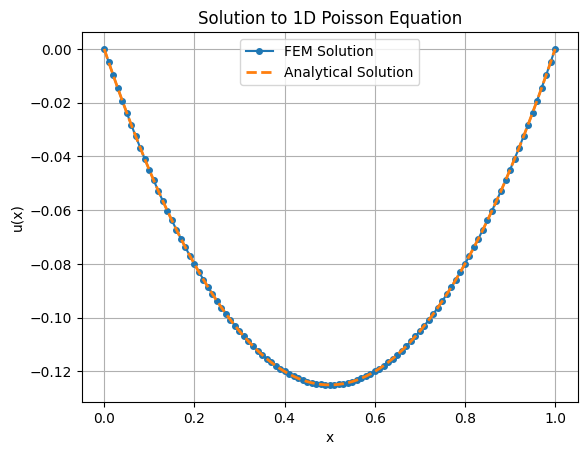

In [11]:
u = np.linalg.solve(K, F)

u_exact = - 0.5 * x * (1 - x) #Analytical Solution

plt.plot(x, u, label='FEM Solution', marker='o', markersize=4)
plt.plot(x, u_exact, '--', label='Analytical Solution', linewidth=2)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Solution to 1D Poisson Equation')
plt.legend()
plt.grid(True)
plt.show()

## Non-Uniform Grids:

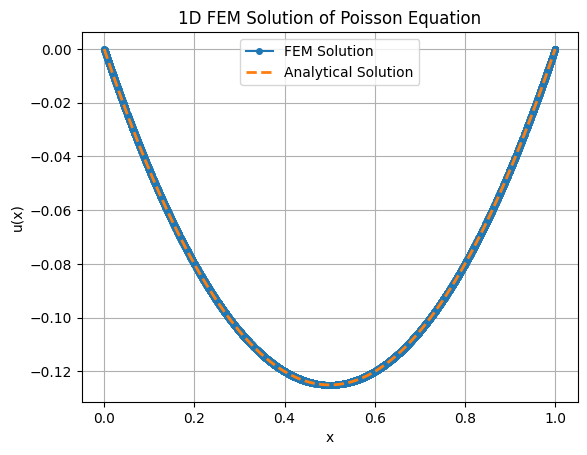

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x2 = np.sort(np.random.rand(10001)) 

K = np.zeros((10001, 10001))
F = np.zeros(10001)         

for i in range(10000):
    h = x2[i+1] - x2[i] 
    
    ke = (1 / h) * np.array([[1, -1], [-1, 1]])
    fe = -(h / 2) * np.array([1, 1])            
    
    K[i:i+2, i:i+2] += ke
    F[i:i+2] += fe

K[0, :] = 0; K[0, 0] = 1; F[0] = 0
K[-1, :] = 0; K[-1, -1] = 1; F[-1] = 0

u2 = np.linalg.solve(K, F)

u_exact = - 0.5 * x2 * (1 - x2) #Analytical Solution


plt.plot(x2, u2, label='FEM Solution', marker='o', markersize=4)
plt.plot(x2, u_exact, '--', label='Analytical Solution', linewidth=2)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('1D FEM Solution of Poisson Equation')
plt.grid(True)
plt.legend()
plt.show()


## References:
1. Larson, Mats & Bengzon, Fredrik. (2013). The Finite Element Method: Theory, Implementation, and Applications. 10.1007/978-3-642-33287-6.
2. Reddy, J. N. (John N.). An Introduction to the Finite Element Method. McGraw-Hill, New York, 1993. 